In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
df=pd.read_csv('synthetic_customer_churn_100k.csv')


In [122]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  str    
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  str    
 6   PaymentMethod   100000 non-null  str    
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 6.9 MB


In [124]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.140256
std,28867.657797,18.177862,20.789552,40.491961,2388.163672
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


In [125]:
df.shape

(100000, 9)

In [126]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='str')

In [127]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [128]:
df=df.drop("CustomerID", axis=1)

In [129]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

In [130]:
df=pd.get_dummies(df, columns=['Contract','PaymentMethod','Gender'], drop_first=True)

In [131]:
df

,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Gender_Male,Gender_Other
0,56,68,147.58,10052.03,0,False,True,False,False,False,False,False
1,69,32,22.54,686.78,0,False,False,False,False,True,True,False
2,46,10,52.47,537.88,0,True,False,False,True,False,False,False
3,32,22,109.67,2390.04,1,False,False,False,False,True,True,False
4,60,54,130.98,7081.28,0,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,31,49,26.07,1220.50,0,False,False,False,True,False,True,False
99996,64,44,123.22,5384.38,0,False,False,False,False,True,False,False
99997,48,32,75.37,2372.33,1,False,False,True,False,False,False,True
99998,42,60,114.00,6826.55,0,False,False,False,False,True,False,False


In [132]:
df.dtypes

Age                                 int64
Tenure                              int64
MonthlyCharges                    float64
TotalCharges                      float64
Churn                               int64
Contract_One year                    bool
Contract_Two year                    bool
PaymentMethod_Credit card            bool
PaymentMethod_Electronic check       bool
PaymentMethod_Mailed check           bool
Gender_Male                          bool
Gender_Other                         bool
dtype: object

In [133]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [134]:
df.dtypes

Age                                 int64
Tenure                              int64
MonthlyCharges                    float64
TotalCharges                      float64
Churn                               int64
Contract_One year                   int64
Contract_Two year                   int64
PaymentMethod_Credit card           int64
PaymentMethod_Electronic check      int64
PaymentMethod_Mailed check          int64
Gender_Male                         int64
Gender_Other                        int64
dtype: object

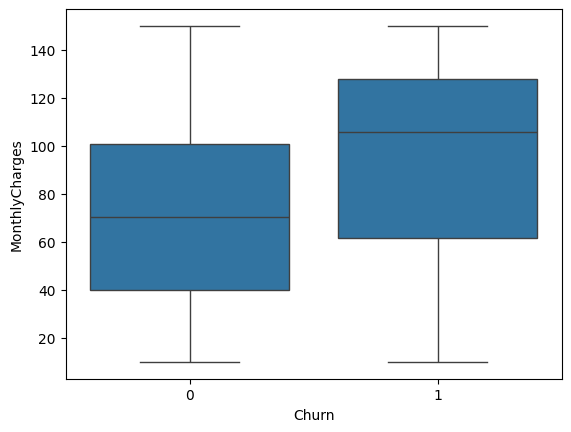

In [135]:
#EDA
sns.boxplot(x='Churn', y='MonthlyCharges',data=df)
plt.show()

In [136]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
0    72.845838
1    94.355298
Name: MonthlyCharges, dtype: float64

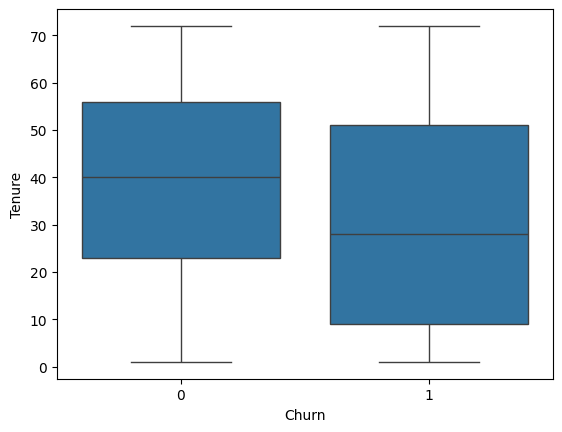

In [137]:
sns.boxplot(x='Churn', y='Tenure',data=df)
plt.show()

In [138]:
df.groupby('Churn')['Tenure'].mean()


Churn
0    39.321796
1    30.889784
Name: Tenure, dtype: float64

In [139]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.66856
1    0.33144
Name: proportion, dtype: float64

In [140]:
df.groupby('Churn')[['Contract_One year','Contract_Two year']].mean()

,Contract_One year,Contract_Two year
Churn,,
0,0.314557,0.246470
1,0.127655,0.100953


In [141]:
df

,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Gender_Male,Gender_Other
0,56,68,147.58,10052.03,0,0,1,0,0,0,0,0
1,69,32,22.54,686.78,0,0,0,0,0,1,1,0
2,46,10,52.47,537.88,0,1,0,0,1,0,0,0
3,32,22,109.67,2390.04,1,0,0,0,0,1,1,0
4,60,54,130.98,7081.28,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,31,49,26.07,1220.50,0,0,0,0,1,0,1,0
99996,64,44,123.22,5384.38,0,0,0,0,0,1,0,0
99997,48,32,75.37,2372.33,1,0,0,1,0,0,0,1
99998,42,60,114.00,6826.55,0,0,0,0,0,1,0,0


In [157]:
#train test split model
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [158]:
X_train

,Age,Tenure,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Gender_Male,Gender_Other
75220,23,17,11.07,263.68,0,0,0,1,0,1,0
48955,26,4,112.82,484.81,0,0,0,1,0,1,0
44966,63,64,14.93,958.34,0,0,0,1,0,0,1
13568,29,31,55.39,1832.05,0,1,0,1,0,1,0
92727,62,2,111.51,259.43,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6265,37,68,58.13,3934.95,1,0,0,0,1,1,0
54886,46,4,86.53,273.69,1,0,0,0,0,1,0
76820,38,31,51.83,1537.79,0,1,0,1,0,1,0
860,22,50,23.97,1211.43,1,0,0,1,0,0,0


In [159]:
df.isnull().sum()

Age                               0
Tenure                            0
MonthlyCharges                    0
TotalCharges                      0
Churn                             0
Contract_One year                 0
Contract_Two year                 0
PaymentMethod_Credit card         0
PaymentMethod_Electronic check    0
PaymentMethod_Mailed check        0
Gender_Male                       0
Gender_Other                      0
dtype: int64

In [160]:
df=df.dropna()

In [161]:
X_test

,Age,Tenure,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Gender_Male,Gender_Other
75721,35,33,22.21,760.73,0,0,1,0,0,0,0
80184,77,29,136.21,3923.22,1,0,1,0,0,1,0
19864,31,58,125.31,7293.29,0,0,0,0,1,1,0
76699,20,48,74.83,3601.89,0,1,0,0,1,0,0
92991,30,66,87.44,5747.30,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
32595,59,6,44.09,204.06,1,0,0,1,0,1,0
29313,21,65,96.49,6268.36,0,1,0,0,1,0,0
37862,33,8,35.53,363.61,1,0,0,0,0,0,0
53421,45,28,100.24,2914.11,0,0,0,0,0,1,0


In [162]:
y_train.shape

(80000,)

In [163]:
y_test.shape

(20000,)

In [164]:
#Model

from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train,y_train)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [165]:
y_pred=model.predict(X_test)

In [166]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.68995
              precision    recall  f1-score   support

           0       0.82      0.68      0.75     13294
           1       0.53      0.70      0.60      6706

    accuracy                           0.69     20000
   macro avg       0.67      0.69      0.67     20000
weighted avg       0.72      0.69      0.70     20000



In [167]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

In [168]:
print(x.columns)

Index(['CustomerID', 'Age', 'Tenure', 'MonthlyCharges', 'TotalCharges',
       'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Gender_Male', 'Gender_Other'],
      dtype='str')


In [169]:
df

,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Gender_Male,Gender_Other
0,56,68,147.58,10052.03,0,0,1,0,0,0,0,0
1,69,32,22.54,686.78,0,0,0,0,0,1,1,0
2,46,10,52.47,537.88,0,1,0,0,1,0,0,0
3,32,22,109.67,2390.04,1,0,0,0,0,1,1,0
4,60,54,130.98,7081.28,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,31,49,26.07,1220.50,0,0,0,0,1,0,1,0
99996,64,44,123.22,5384.38,0,0,0,0,0,1,0,0
99997,48,32,75.37,2372.33,1,0,0,1,0,0,0,1
99998,42,60,114.00,6826.55,0,0,0,0,0,1,0,0


In [170]:
print(X.columns)
print(len(X.columns))

Index(['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Credit card',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Gender_Male', 'Gender_Other'],
      dtype='str')
11
